In [8]:
import pandas
import numpy
import matplotlib.pyplot as pyplot
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage


In [9]:
# Task 1

dataFrame = pandas.read_csv('Wholesale customers data.csv')


print(f"\nThe dataFrame has {dataFrame.shape[1]} columns and {dataFrame.shape[0]} rows.")


print(f"\n{dataFrame.head()}")



The dataFrame has 7 columns and 440 rows.

   Channel  Region  Fresh  Milk  Grocery  Frozen  Delicassen
0        2       3  12669  9656     7561     214        1338
1        2       3   7057  9810     9568    1762        1776
2        2       3   6353  8808     7684    2405        7844
3        1       3  13265  1196     4221    6404        1788
4        2       3  22615  5410     7198    3915        5185


In [10]:
dataFrame = dataFrame.dropna(axis=1, how='all')

numericTypes = dataFrame.select_dtypes(include=[numpy.number])
numericColumns = numericTypes.columns

for column in numericColumns:
    if dataFrame[column].isna().any():
        dataFrame[column].fillna(dataFrame[column].mean(), inplace=True)

metaColumns = []
for column in dataFrame.columns:
    if dataFrame[column].dtype == 'object':
        metaColumns.append(column)
    elif column.lower() == 'region':
        metaColumns.append(column)
    elif column.lower() == 'channel':
        metaColumns.append(column)

numericColumns = []
for column in dataFrame.columns:
    if column not in metaColumns:
        numericColumns.append(column)

print('\nNumeric feature columns:', numericColumns)

scaler = StandardScaler()
scaledFeatures = scaler.fit_transform(dataFrame[numericColumns])
scaledDataFrame = pandas.DataFrame(scaledFeatures, columns=numericColumns)

scaledDataFrame.to_csv('Preprocessed Data.csv', index=False)

print('\n', scaledDataFrame.head())



Numeric feature columns: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Delicassen']

       Fresh      Milk   Grocery    Frozen  Delicassen
0  0.052933  0.523568 -0.041115 -0.589367   -0.066339
1 -0.391302  0.544458  0.170318 -0.270136    0.089151
2 -0.447029  0.408538 -0.028157 -0.137536    2.243293
3  0.100111 -0.624020 -0.392977  0.687144    0.093411
4  0.840239 -0.052396 -0.079356  0.173859    1.299347


c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



k = 2, Inertia = 432.39


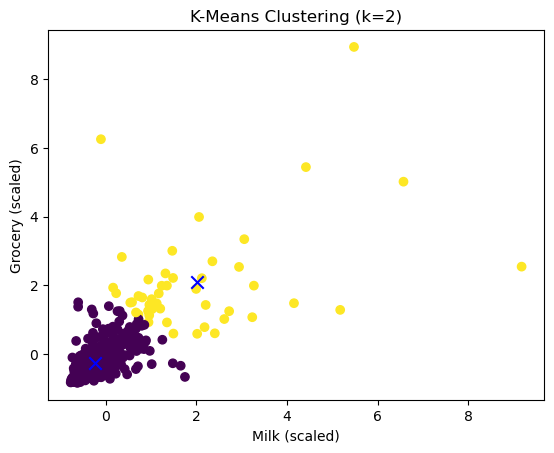


k = 3, Inertia = 274.06


c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


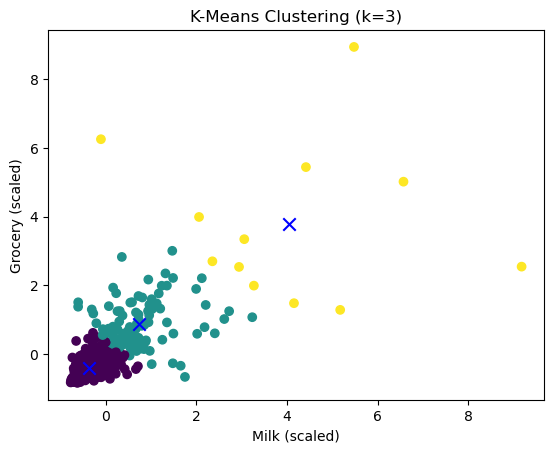

c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



k = 4, Inertia = 191.33


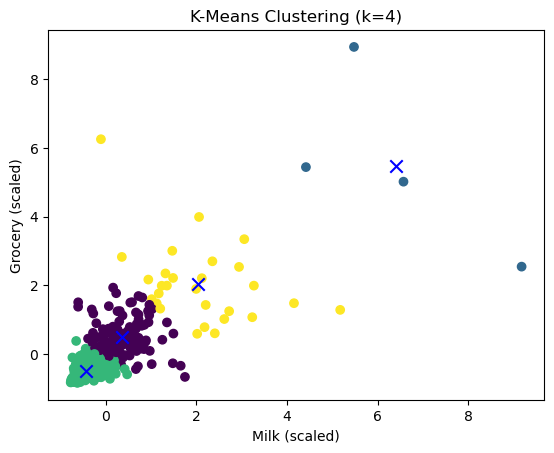

c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



k = 5, Inertia = 157.44


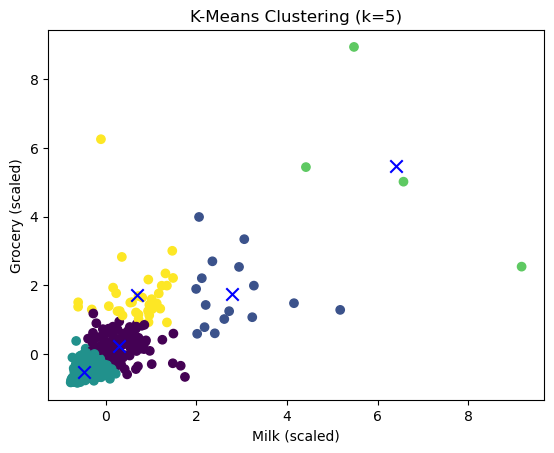

c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



k = 6, Inertia = 134.61


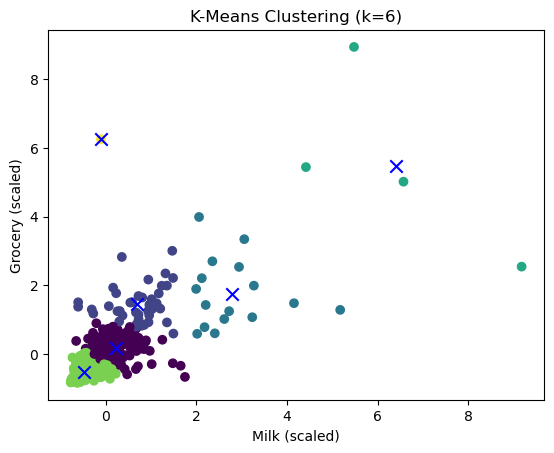

c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



k = 7, Inertia = 114.33


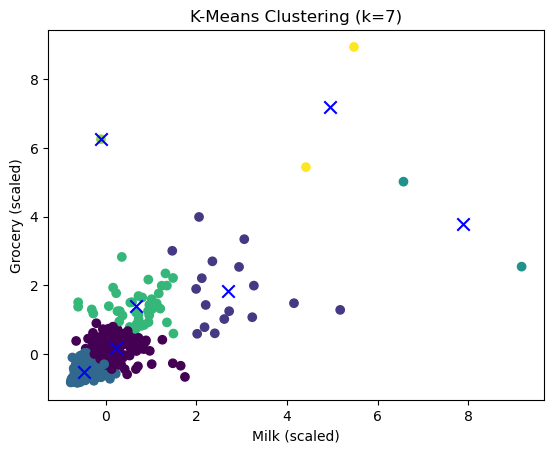

c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\cluster\_kmeans.py:1334: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\clust

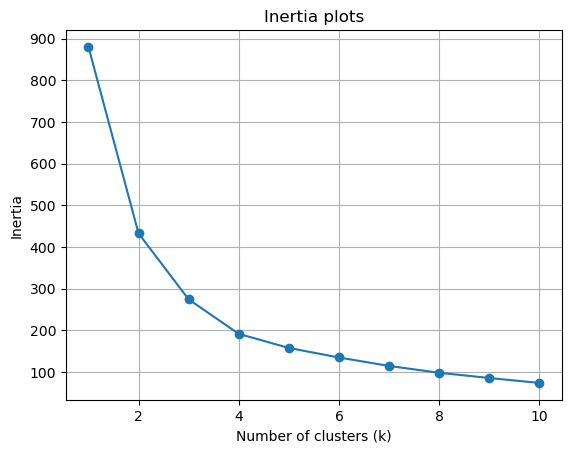

In [11]:
#Task 2

featureData = dataFrame[['Milk', 'Grocery']]

scaler = StandardScaler()
scaledFeatures = scaler.fit_transform(featureData)

for clusterCount in [2, 3, 4, 5, 6, 7]:
    kMeansModel = KMeans(n_clusters=clusterCount, random_state=0)
    labels = kMeansModel.fit_predict(scaledFeatures)
    print(f'\nk = {clusterCount}, Inertia = {kMeansModel.inertia_:.2f}')
    pyplot.scatter(scaledFeatures[:, 0], scaledFeatures[:, 1], c=labels)
    pyplot.scatter(
        kMeansModel.cluster_centers_[:, 0],
        kMeansModel.cluster_centers_[:, 1],
        c='blue',
        marker='x',
        s=80
    )
    pyplot.xlabel('Milk (scaled)')
    pyplot.ylabel('Grocery (scaled)')
    pyplot.title(f'K-Means Clustering (k={clusterCount})')
    pyplot.show()

inertiaValues = []
clusterRange = range(1, 11)

for clusterCount in clusterRange:
    kMeansModel = KMeans(n_clusters=clusterCount, random_state=0)
    kMeansModel.fit(scaledFeatures)
    inertiaValues.append(kMeansModel.inertia_)

pyplot.plot(clusterRange, inertiaValues, marker='o')
pyplot.title('Inertia plots')
pyplot.xlabel('Number of clusters (k)')
pyplot.ylabel('Inertia')
pyplot.grid(True)
pyplot.show()


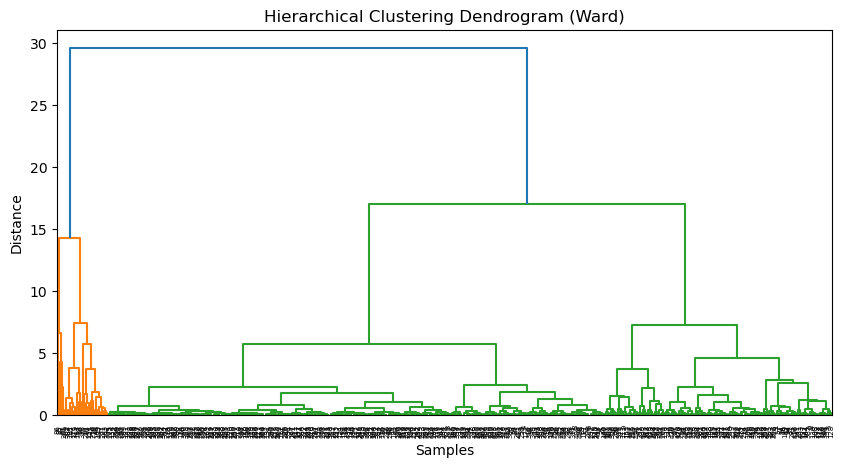

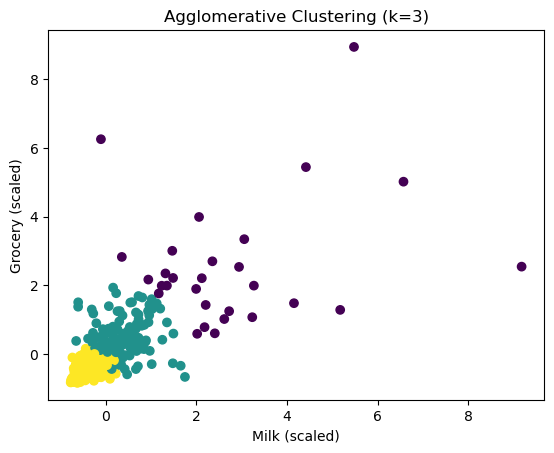

In [12]:
linkageMatrix = linkage(scaledFeatures, method='ward')

pyplot.figure(figsize=(10, 5))
dendrogram(linkageMatrix)
pyplot.title('Hierarchical Clustering Dendrogram (Ward)')
pyplot.xlabel('Samples')
pyplot.ylabel('Distance')
pyplot.show()

hierarchicalModel = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchicalLabels = hierarchicalModel.fit_predict(scaledFeatures)

pyplot.scatter(scaledFeatures[:, 0], scaledFeatures[:, 1], c=hierarchicalLabels)
pyplot.xlabel('Milk (scaled)')
pyplot.ylabel('Grocery (scaled)')
pyplot.title('Agglomerative Clustering (k=3)')
pyplot.show()


In [13]:
#Task 3

dataFrame['kmeans_cluster'] = kMeansModel.labels_
dataFrame['agg_cluster'] = hierarchicalLabels

centroidDataFrame = pandas.DataFrame(
    kMeansModel.cluster_centers_,
    columns=['Milk', 'Grocery']
)

agglomerativeCentroids = dataFrame.groupby('agg_cluster')[['Milk', 'Grocery']].mean()

kMeansSilhouette = silhouette_score(scaledFeatures, dataFrame['kmeans_cluster'])
agglomerativeSilhouette = silhouette_score(scaledFeatures, dataFrame['agg_cluster'])

print('\nKMeans silhouette:', kMeansSilhouette)
print('\nAgglomerative silhouette:', agglomerativeSilhouette)

print('\nKMeans cluster sizes:\n', dataFrame['kmeans_cluster'].value_counts().sort_index())
print('\nAgglomerative cluster sizes:\n', dataFrame['agg_cluster'].value_counts().sort_index())

print('\nKMeans cluster centroids:\n', centroidDataFrame.round(2).assign(Method='KMeans'))
print('\nAgglomerative cluster centroids:\n', agglomerativeCentroids.round(2).assign(Method='Agglomerative'))



KMeans silhouette: 0.44926581776953767

Agglomerative silhouette: 0.5410620732723127

KMeans cluster sizes:
 kmeans_cluster
0    203
1     24
2      3
3    106
4     10
5      1
6      9
7      1
8     49
9     34
Name: count, dtype: int64

Agglomerative cluster sizes:
 agg_cluster
0     29
1    129
2    282
Name: count, dtype: int64

KMeans cluster centroids:
    Milk  Grocery  Method
0 -0.56    -0.59  KMeans
1  0.83     1.53  KMeans
2  5.49     6.46  KMeans
3 -0.10    -0.18  KMeans
4  3.00     1.15  KMeans
5  9.18     2.55  KMeans
6  2.09     2.69  KMeans
7 -0.11     6.25  KMeans
8  0.64     0.30  KMeans
9 -0.06     0.70  KMeans

Agglomerative cluster centroids:
                  Milk   Grocery         Method
agg_cluster                                   
0            25962.10  32403.66  Agglomerative
1             8515.22  12620.36  Agglomerative
2             2478.70   3300.82  Agglomerative


In [14]:
# Task 4

regionLabels = dataFrame['Region'].values

trainFeatures, testFeatures, trainLabels, testLabels = train_test_split(
    scaledFeatures, regionLabels, test_size=0.3, random_state=42, stratify=regionLabels
)

supportVectorModel = SVC(kernel='rbf', random_state=42)
supportVectorModel.fit(trainFeatures, trainLabels)
predictedLabels = supportVectorModel.predict(testFeatures)

print('\nSVM Classification Report:\n', classification_report(testLabels, predictedLabels))
print('\nSVM Accuracy:', accuracy_score(testLabels, predictedLabels))

clusterMapping = {}

for clusterLabel in dataFrame['kmeans_cluster'].unique():
    regionValues, regionCounts = numpy.unique(
        dataFrame['Region'].values[dataFrame['kmeans_cluster'] == clusterLabel],
        return_counts=True
    )
    dominantRegion = regionValues[regionCounts.argmax()]
    clusterMapping[clusterLabel] = dominantRegion

print('\nCluster → Region Mapping:', clusterMapping)

mappedRegions = numpy.array([clusterMapping.get(cluster, -1) for cluster in dataFrame['kmeans_cluster']])
mappingAccuracy = numpy.mean(mappedRegions == dataFrame['Region'].values)

print('\nCluster Mapping Accuracy:', mappingAccuracy)



SVM Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00        23
           2       0.00      0.00      0.00        14
           3       0.72      1.00      0.84        95

    accuracy                           0.72       132
   macro avg       0.24      0.33      0.28       132
weighted avg       0.52      0.72      0.60       132


SVM Accuracy: 0.7196969696969697

Cluster → Region Mapping: {8: 3, 0: 3, 3: 3, 1: 3, 9: 3, 4: 3, 6: 3, 2: 3, 5: 3, 7: 2}

Cluster Mapping Accuracy: 0.7204545454545455


c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Muntashir\anaconda3\envs\DataMining\Lib\site-packages\sklearn\metrics\_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(resu